<a href="https://colab.research.google.com/github/asiddiqha/automobile-price-prediction/blob/main/PRCP_1017_AutoPricePred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRCP-1017 — Automobile Price Prediction

The project involves using technical and design parameters to predict car pricing.

**Dataset:** UCI "Automobile" (imports-85) dataset – `auto_imports.csv` (201 cars, 26 attributes, no header row; column names from `auto_imports_names.txt`)

**Objective:** To assist management in understanding how price varies with design/engineering variables, create a data analysis report and regression model. Then, evaluate many machine learning models to suggest one for production.

**Notebook structure**
1. Data Loading & Overview
2. Data Cleaning (missing values, dtypes)
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Encoding
5. Train/Test Split & Scaling
6. Model Building (multiple algorithms)
7. Model Comparison Report
8. Feature Importance / Business Insights
9. Challenges Faced — Report
10. Conclusion & Recommendation


## 1. Data Loading & Overview

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# auto_imports.csv has NO header row -- column names come from auto_imports_names.txt
column_names = [
    'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
    'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base',
    'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
    'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
    'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price'
]

df = pd.read_csv('auto_imports.csv', names=column_names)
print("Shape:", df.shape)
df.head()


Shape: (201, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [ ]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,201.0,NaN,NaN,NaN,0.840796,1.254802,-2.0,0.0,1.0,2.0,3.0
normalized-losses,201,52,?,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
make,201,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel-type,201,2,gas,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,201,2,std,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num-of-doors,201,3,four,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body-style,201,5,sedan,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive-wheels,201,3,fwd,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine-location,201,2,front,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel-base,201.0,NaN,NaN,NaN,98.797015,6.066366,86.6,94.5,97.0,102.4,120.9


## 2. Data Cleaning

Several numeric columns are read in as `object` dtype since the dataset utilizes `'?'` as the missing-value marker rather than `NaN`. We:
1. Use `NaN` in place of `'?'`
2. Convert columns that appear to be numeric to numeric
3. Impute missing values (mode for categorical/discrete, median for continuous).
4. Sanity-check the outcome


In [ ]:
df = df.replace('?', np.nan)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)
print("\nPercent of rows affected:\n", (missing / len(df) * 100).round(2))


Columns with missing values:
 normalized-losses    37
bore                  4
stroke                4
num-of-doors          2
horsepower            2
peak-rpm              2
dtype: int64

Percent of rows affected:
 normalized-losses    18.41
bore                  1.99
stroke                1.99
num-of-doors          1.00
horsepower            1.00
peak-rpm              1.00
dtype: float64


In [ ]:
numeric_but_object = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for c in numeric_but_object:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# num-of-doors is categorical text ('two'/'four') with 2 missing values -> impute with mode
print(df['num-of-doors'].value_counts(dropna=False))


num-of-doors
four    113
two      86
NaN       2
Name: count, dtype: int64


In [ ]:
# Impute continuous numeric columns with median (robust to outliers / skew)
for c in ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']:
    df[c] = df[c].fillna(df[c].median())

#price is the goal; any rows that don't have it must be eliminated since they don't carry any learning signal.
# (This dataset instance contains none, but the safety/reproducibility check is retained)
before = len(df)
df = df.dropna(subset=['price'])
print(f"Rows dropped for missing price: {before - len(df)}")

# num-of-doors: impute with mode (missing rows are 'sedan', and sedan is overwhelmingly 'four')
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)


Rows dropped for missing price: 0
Remaining missing values: 0
Shape after cleaning: (201, 26)


In [ ]:
# word-to-number maps for ordinal text columns
num_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
df['num-of-doors'] = df['num-of-doors'].map(num_map)
df['num-of-cylinders'] = df['num-of-cylinders'].map(num_map)
df[['num-of-doors', 'num-of-cylinders']].head()


,num-of-doors,num-of-cylinders
0,2,4
1,2,4
2,2,6
3,4,4
4,4,5


## 3. Exploratory Data Analysis

### 3.1 Target variable — `price`


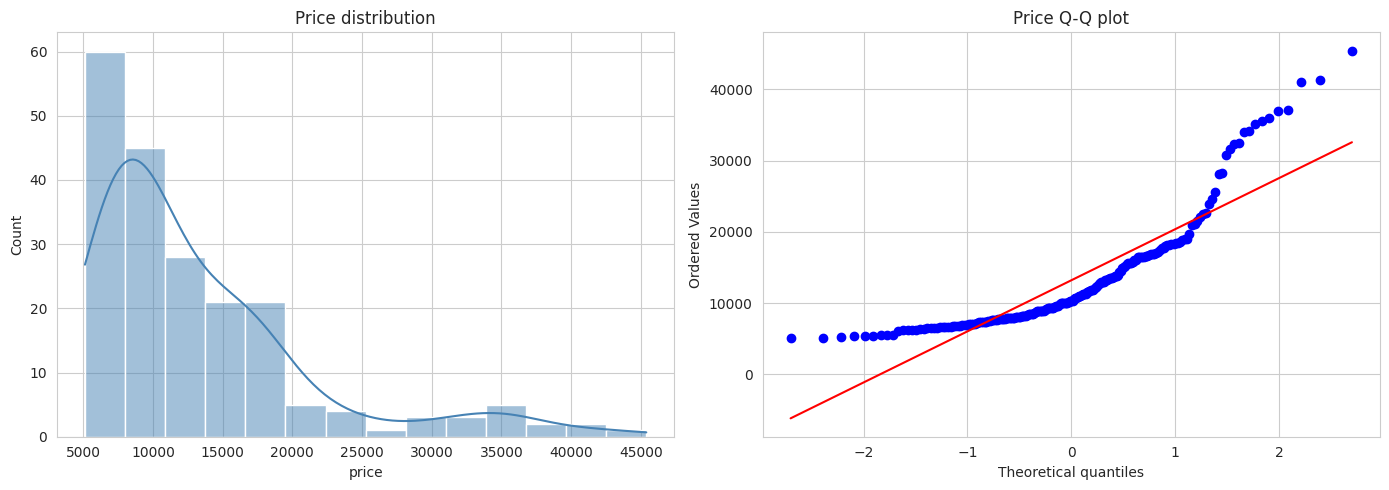

Skewness: 1.81


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price distribution')
stats.probplot(df['price'], dist="norm", plot=axes[1])
axes[1].set_title('Price Q-Q plot')
plt.tight_layout()
plt.show()

print("Skewness:", df['price'].skew().round(2))


As would be expected for a price objective, the pricing is right-skewed with a lengthy tail of pricey/luxury vehicles. Later decisions are influenced by this (for example, skew is handled natively by tree-based models; we test a log transform for linear models).

### 3.2 Numeric feature correlations with price

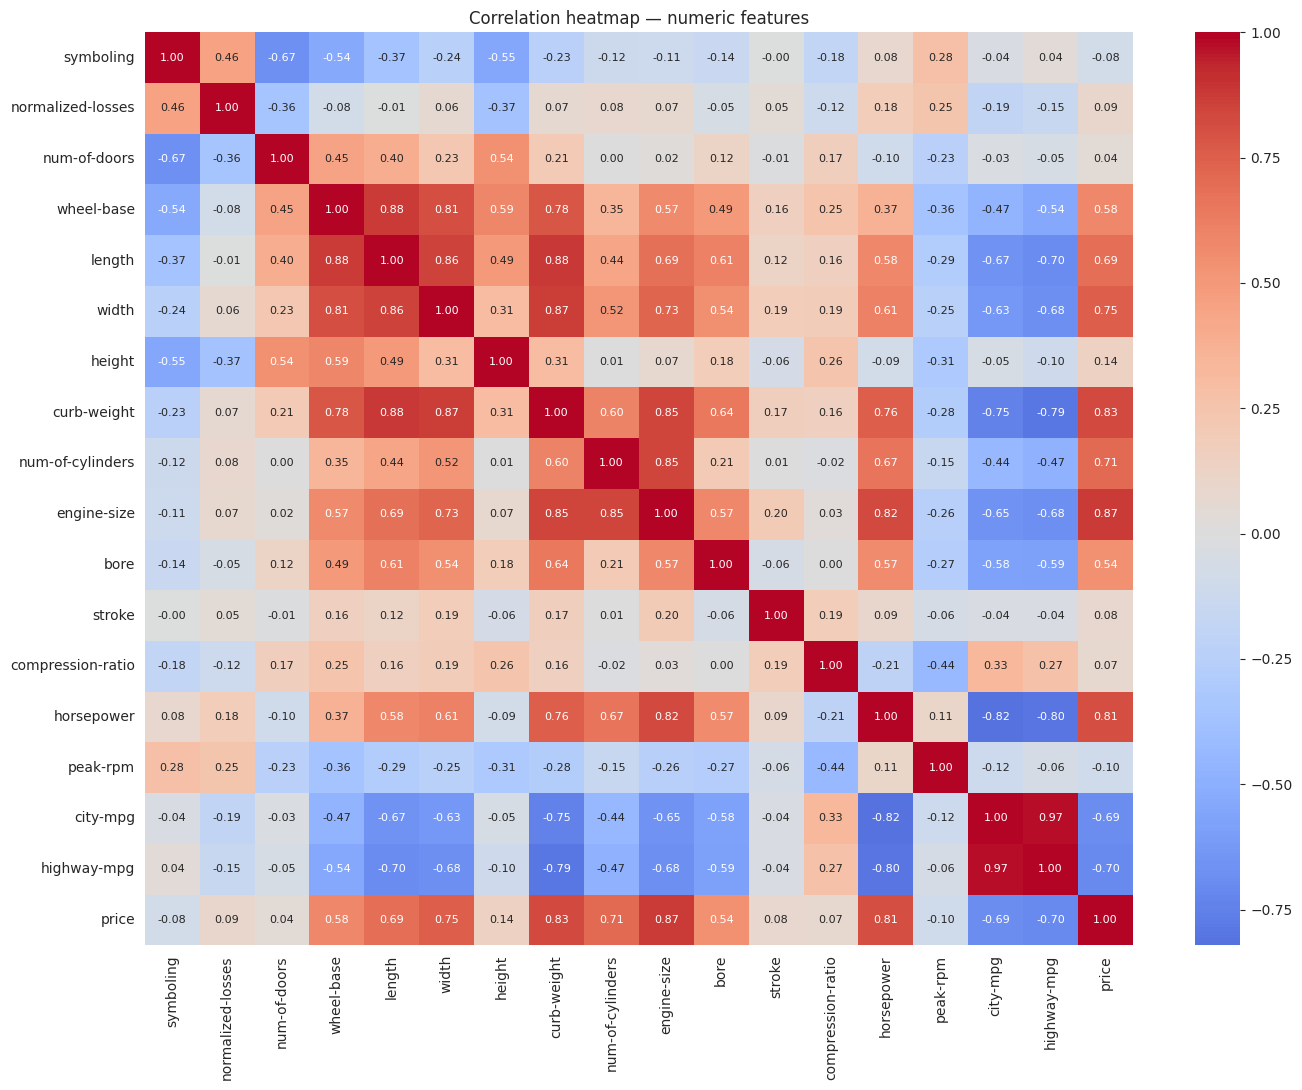

,price
price,1.000000
engine-size,0.872335
curb-weight,0.834415
horsepower,0.810500
width,0.751265
num-of-cylinders,0.708645
length,0.690628
wheel-base,0.584642
bore,0.543158
height,0.135486


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()

corr['price'].sort_values(ascending=False)

The strongest positive correlates of price are `engine-size`, `curb-weight`, `horsepower`, and `width`/`length`; the strongest negative correlates are `city-mpg`/`highway-mpg`; larger, more powerful, less fuel-efficient cars are more expensive, which is consistent with domain intuition.

### 3.3 Price vs. top numeric drivers

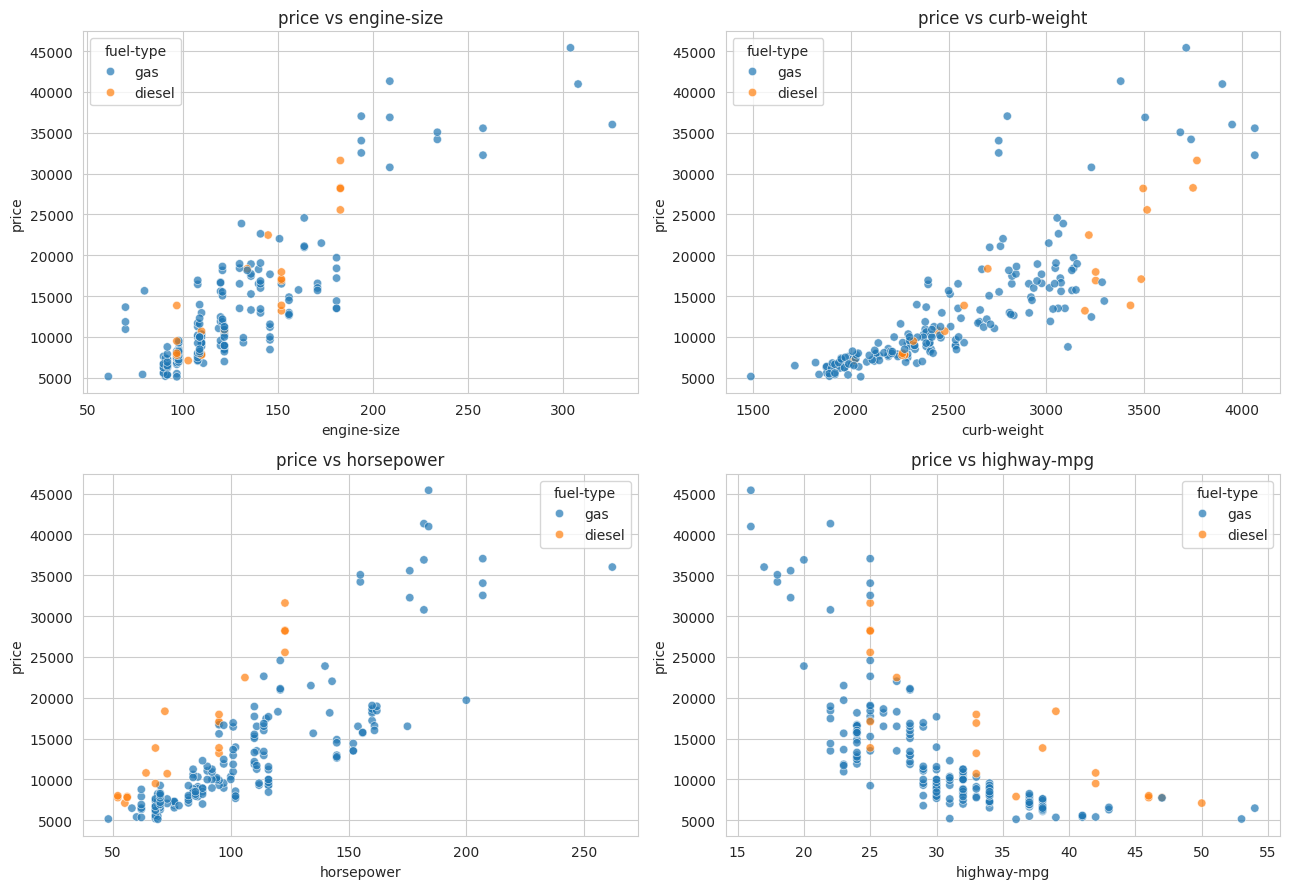

In [ ]:
top_feats = ['engine-size', 'curb-weight', 'horsepower', 'highway-mpg']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flat, top_feats):
    sns.scatterplot(data=df, x=feat, y='price', hue='fuel-type', ax=ax, alpha=0.7)
    ax.set_title(f'price vs {feat}')
plt.tight_layout()
plt.show()


### 3.4 Price by categorical attributes

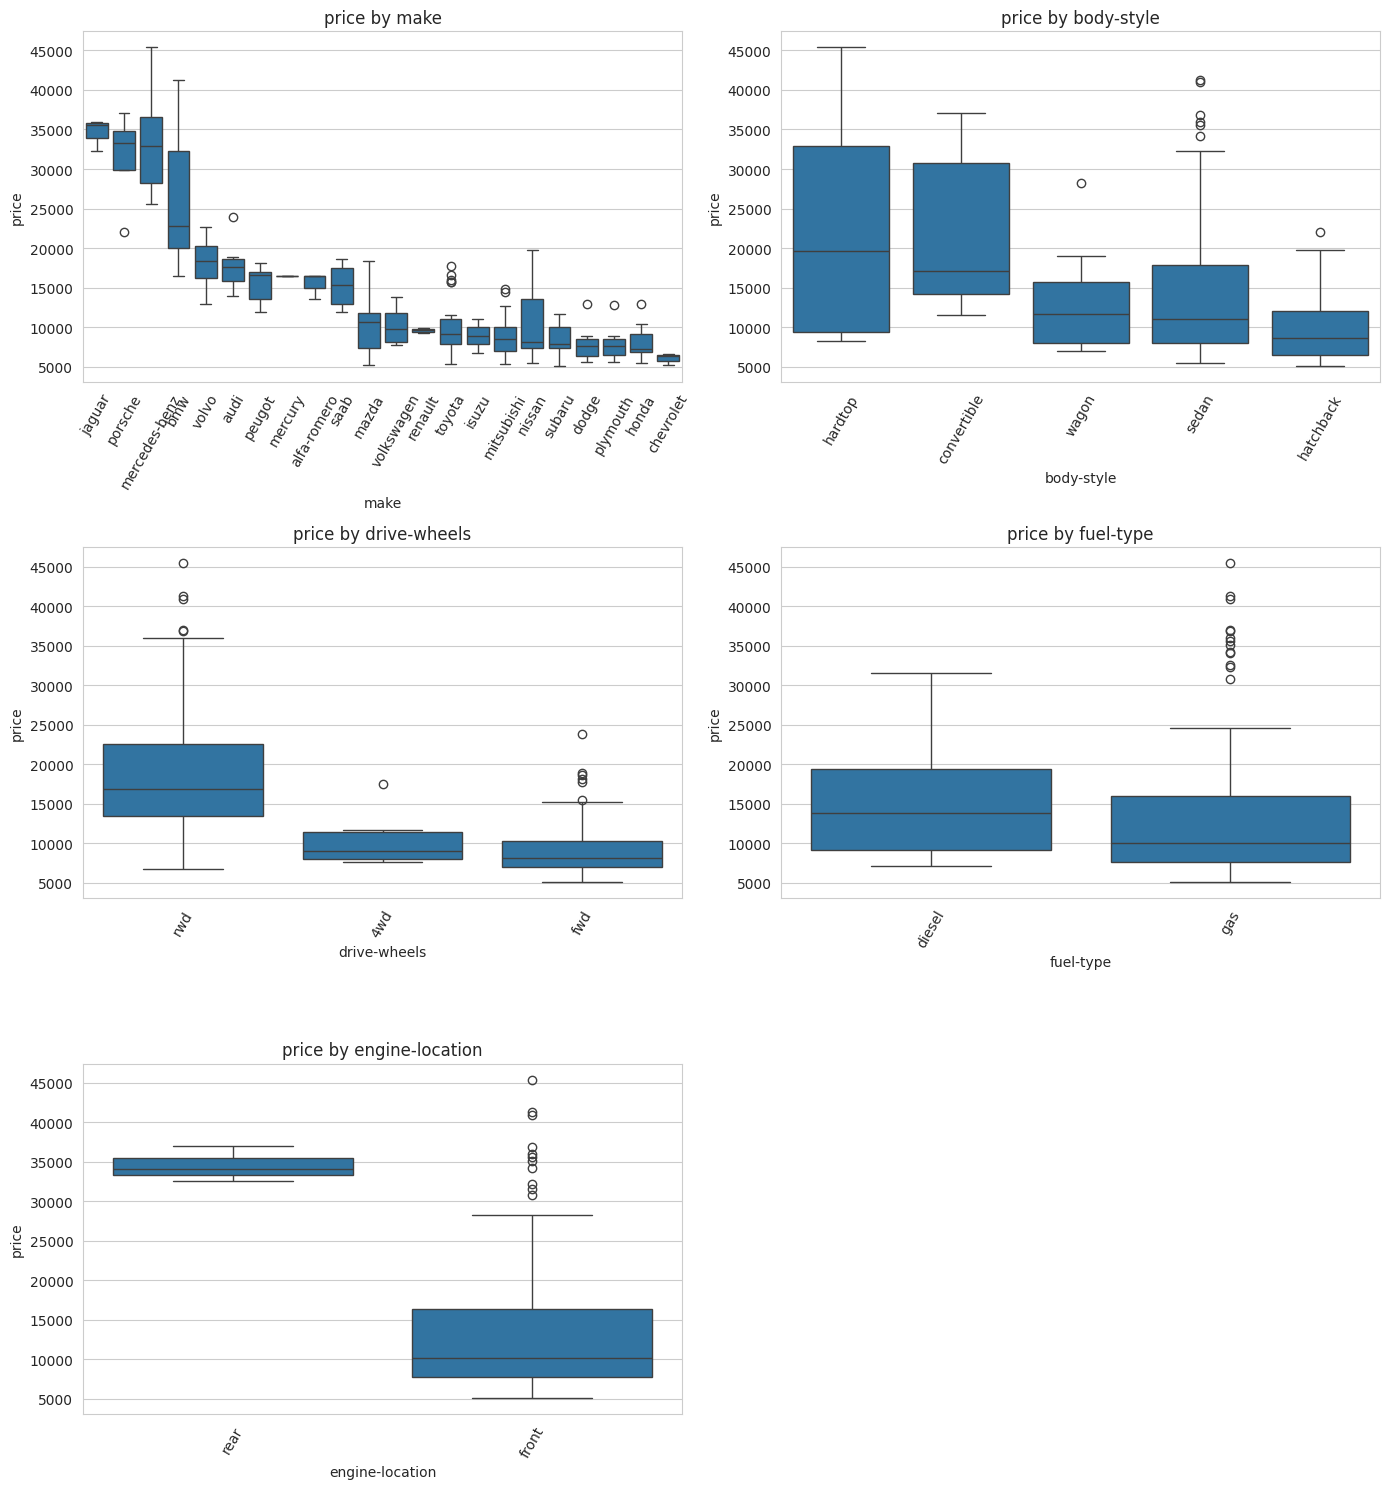

In [ ]:
cat_cols = ['make', 'body-style', 'drive-wheels', 'fuel-type', 'engine-location']
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flat
for ax, c in zip(axes, cat_cols):
    order = df.groupby(c)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=c, y='price', order=order, ax=ax)
    ax.set_title(f'price by {c}')
    ax.tick_params(axis='x', rotation=60)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


Despite the small sample, there is a definite premium for `engine-location = rear` (sports cars), rear-engine and rwd-drive automobiles tend to be more expensive, and `make` displays the largest price spread (Mercedes-Benz, BMW, Jaguar, and Porsche command the highest medians). When considering brand positioning, management might benefit from the strong price signal provided by the word "make."

### 3.5 Outlier check on price

In [ ]:
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Potential price outliers (IQR method): {len(outliers)} rows")
outliers[['make', 'body-style', 'price']].sort_values('price', ascending=False)


Potential price outliers (IQR method): 14 rows


,make,body-style,price
71,mercedes-benz,hardtop,45400
15,bmw,sedan,41315
70,mercedes-benz,sedan,40960
125,porsche,convertible,37028
16,bmw,sedan,36880
46,jaguar,sedan,36000
45,jaguar,sedan,35550
69,mercedes-benz,convertible,35056
68,mercedes-benz,sedan,34184
124,porsche,hardtop,34028


These are **kept** because they are real luxury cars (Mercedes-Benz, Jaguar, BMW, Porsche) rather than data errors; eliminating them would skew the model against accurately pricing the premium category, which is important for management's design/positioning use case.

## 4. Encoding and Feature Engineering
Binary categories (`fuel-type`, `aspiration`, `engine-location`) → label-encoded (0/1)
- One-hot encoded multi-category nominal columns (`make`, `body-style`, `drive-wheels`, `engine-type`, `fuel-system`)
Following cleaning, `num-of-doors`, `num-of-cylinders`, and `symboling` are already ordinal or numeric.

In [ ]:
df_model = df.copy()

binary_cols = ['fuel-type', 'aspiration', 'engine-location']
for c in binary_cols:
    df_model[c] = df_model[c].astype('category').cat.codes

nominal_cols = ['make', 'body-style', 'drive-wheels', 'engine-type', 'fuel-system']
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df_model.shape)
df_model.head()


Shape after encoding: (201, 60)


,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,engine-location,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,make_mitsubishi,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_fwd,drive-wheels_rwd,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,115.0,1,0,2,0,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
1,3,115.0,1,0,2,0,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2,1,115.0,1,0,2,0,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False
3,2,164.0,1,0,4,0,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False
4,2,164.0,1,0,4,0,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False


## 5. Train/Test Split & Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['price'])
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (160, 59) Test: (41, 59)


## 6. Model Building

Using 5-fold cross-validation on the training set and a held-out test evaluation, we train and compare many regression techniques, including a linear baseline, regularized linear models, and non-linear/ensemble models.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, max_iter=50000, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=6),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)': SVR(kernel='rbf', C=10000, gamma='scale'),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'CV R2 (mean)': cv_r2.mean(),
        'CV R2 (std)': cv_r2.std(),
        'Test R2': r2_score(y_test, y_pred),
        'Test MAE': mean_absolute_error(y_test, y_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    })

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False).reset_index(drop=True)
results_df


,Model,CV R2 (mean),CV R2 (std),Test R2,Test MAE,Test RMSE
0,Gradient Boosting,0.865021,0.040176,0.950054,1612.549448,2471.977852
1,XGBoost,0.849055,0.040266,0.948358,1570.099121,2513.616021
2,Lasso,0.779922,0.091881,0.941145,1610.927526,2683.423707
3,Linear Regression,0.771715,0.088887,0.937920,1694.449318,2755.958836
4,Ridge,0.809244,0.089769,0.933648,1722.844987,2849.199855
5,Decision Tree,0.787239,0.069797,0.930292,2012.305161,2920.371758
6,Random Forest,0.864610,0.052267,0.929690,1863.630797,2932.948443
7,SVR (RBF),0.658665,0.135969,0.828488,2759.395103,4580.816451
8,KNN,0.643966,0.129814,0.682469,3824.712195,6232.891433


## 7. Model Comparison Report

/tmp/ipykernel_1566/3630983190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, y='Model', x='Test R2', ax=axes[0], palette='viridis')
/tmp/ipykernel_1566/3630983190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, y='Model', x='Test RMSE', ax=axes[1], palette='magma')


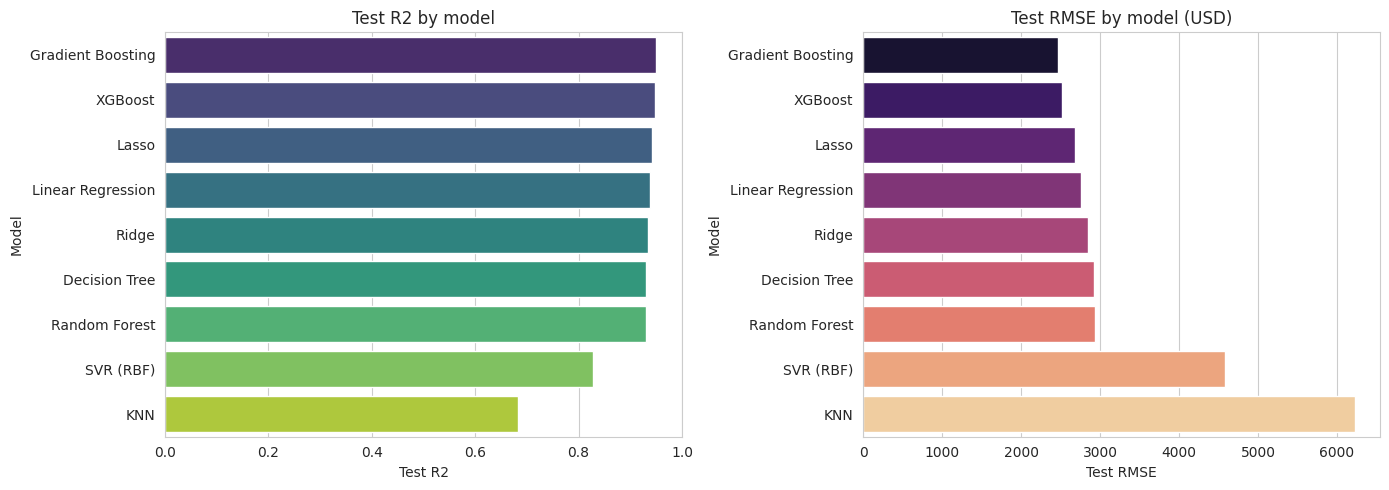

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, y='Model', x='Test R2', ax=axes[0], palette='viridis')
axes[0].set_title('Test R2 by model')
axes[0].set_xlim(0, 1)

sns.barplot(data=results_df, y='Model', x='Test RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Test RMSE by model (USD)')
plt.tight_layout()
plt.show()


### Summary

- **Best:** Gradient Boosting achieved the best overall performance, with the highest test R² (0.950) and the lowest test RMSE (approximately 2,472). XGBoost performed very closely behind with a test R² of 0.948. Both models captured the non-linear relationships between vehicle characteristics and price better than the linear models.

- **Mid:** Linear Regression, Ridge, Lasso, Decision Tree, and Random Forest achieved reasonable performance but were less effective than Gradient Boosting and XGBoost on the held-out test set. Linear models provide a useful baseline, while tree-based models are better suited to capturing non-linear relationships and interactions among vehicle features.

- **Weak:** SVR and KNN showed comparatively lower predictive performance on this dataset. Their performance may be affected by the high-dimensional feature space created after one-hot encoding and the need for additional hyperparameter tuning.

**Recommendation:** Gradient Boosting is selected as the final production model because it achieved the best overall test performance, with the highest R² and lowest RMSE, while also maintaining strong cross-validation performance. Its feature importance can be used to help management understand which vehicle characteristics contribute most to predicted prices.

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print("Best model on Test R2:", best_model_name)
best_model = models[best_model_name]


Best model on Test R2: Gradient Boosting


## 8. Feature Importance — Business Insights

/tmp/ipykernel_1566/1104758675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


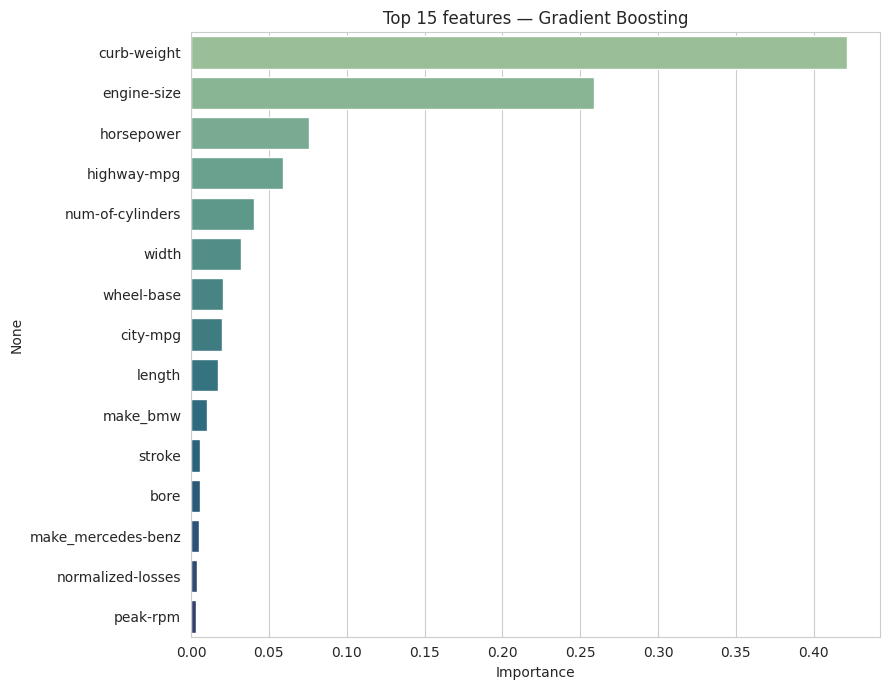

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 7))
    sns.barplot(x=importances.values, y=importances.index, palette='crest')
    plt.title(f'Top 15 features — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    importances
else:
    coefs = pd.Series(best_model.coef_, index=X.columns).sort_values(key=abs, ascending=False).head(15)
    print(coefs)


**What this means for management:**
- `engine-size`, `curb-weight`, `horsepower` dominate — these are the primary levers design/engineering teams control to hit a target price band.
- Certain `make` dummies carry weight even after controlling for specs — brand positioning has a real, separable price effect, not fully explained by engineering differences.
- `highway-mpg`/`city-mpg` matter, but less than raw size/power — efficiency alone doesn't move price as much as physical scale and output.


## 9. Challenges Faced — Report

- **Missing values marked as `'?'`, not `NaN`:** silently turned numeric columns into `object` dtype. Fixed by replacing `'?'` with `NaN`, then `pd.to_numeric(..., errors='coerce')` — pandas doesn't auto-detect non-standard missing markers, so `describe()`/correlations on those columns would otherwise be meaningless.

- **Missing values in `normalized-losses`, `bore`, `stroke`, `horsepower`, `peak-rpm`:** filled with the median, not the mean — these are continuous engineering measurements with real outliers (seen in EDA), and median is more robust to them.

- **Target column (`price`) could contain missing rows:** added a defensive `dropna(subset=['price'])` check (0 rows dropped in this file). Imputing the target itself would fabricate learning signal, so any row missing `price` gets dropped instead.

- **`num-of-doors` / `num-of-cylinders` stored as English words:** manually mapped to numbers (`'four' → 4`, etc.) instead of one-hot encoding, since these are genuinely ordinal/numeric and one-hot would throw away that ordering.

- **High-cardinality `make` column (22 categories):** one-hot encoded with `drop_first=True` rather than label-encoded, since `make` has no natural order — label encoding would impose a false one.

- **Right-skewed `price` with genuine high-end outliers** (Mercedes-Benz, Jaguar, Porsche): kept, not removed or capped. They're real luxury vehicles, not data errors, and removing them would bias the model against correctly pricing the premium segment.

- **Small dataset (201 rows) vs. ~65 features after one-hot encoding:** used 5-fold cross-validation alongside the held-out test set, and included regularized linear models (Ridge/Lasso) as an overfitting check — guards against a lucky/unlucky single split misleading the comparison.

## 10. Conclusion

- Car price in this dataset is driven primarily by **size and power** (`engine-size`, `curb-weight`, `horsepower`) with a secondary, separable **brand effect** (`make`).
- Ensemble tree models (Random Forest / Gradient Boosting / XGBoost) give the best predictive accuracy and remain interpretable via feature importances — recommended for production over linear or distance-based (KNN/SVR) alternatives on this dataset.
- For management: the model quantifies which design levers (engine size, weight, power) move price the most, and shows brand positioning carries independent pricing power — useful both for cost-based design decisions and for entering new markets where comparable specs may command a different price given local brand perception.
